## Hierarchial Clustering

In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram 
import pandas as pd
import numpy as np 
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt 

In [3]:
featureSelection_df = pd.read_csv('corr_featured_data.csv') 

In [4]:
featureSelection_df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,loan_status
0,-1.092709,-1.065582,0.086322,-0.189980,-1.355767,0.037262,-0.656393,0,0
1,-0.449204,-1.065582,-0.937026,0.667245,-0.644230,0.574790,3.744111,0,1
2,-0.770957,-0.006651,-0.169515,0.667245,4.020295,1.308065,3.369600,0,1
3,-0.610081,-0.216922,0.853833,0.667245,4.020295,1.009783,3.556855,1,1
4,-1.092709,-1.059899,-0.681189,-1.047206,-1.118588,-1.205578,0.748023,0,1


In [5]:
x_cluster = featureSelection_df.drop('loan_status', axis= 1) 

In [5]:
range_n_clusters = range(2, 10)     # Try cluster numbers from 2 to 9

### Single Linkage

In [6]:
single_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='single',
        metric= 'euclidean' 
    )
    
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    single_link_scores.append(score)

print("Single scores:", single_link_scores)

Single scores: [0.9019120842305416, 0.851662885156642, 0.8516189363193326, 0.8516003329193753, 0.8418827673191532, 0.8405283908028566, 0.7304124670031905, 0.5968328239903558]


### Ward Linkage

In [7]:
ward_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward', 
        metric= 'euclidean'
    )
    
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    ward_link_scores.append(score)

print("Ward scores:", ward_link_scores)

Ward scores: [0.12235652341981228, 0.13364448047527408, 0.15094932633607072, 0.1541227400543926, 0.09758882854854944, 0.10884156700559004, 0.11688981658369692, 0.11919994294906311]


### Complete Linkage

In [8]:
complete_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='complete', 
        metric= 'euclidean'
    )
    
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    complete_link_scores.append(score)

print("Complete scores:", complete_link_scores)

Complete scores: [0.8757188043938852, 0.7475284186621075, 0.7474961220691012, 0.410740499078023, 0.19476068520484863, 0.1706449425780697, 0.14341587390519667, 0.14125036074361857]


### Average Linkage

In [9]:
average_link_scores = []

for k in range_n_clusters:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='average', 
        metric= 'euclidean'
    )
    
    labels = model.fit_predict(x_cluster)
    score = silhouette_score(x_cluster, labels)
    average_link_scores.append(score)

print("Average scores:", average_link_scores)

Average scores: [0.8757188043938852, 0.851662885156642, 0.7007925210103974, 0.5680471408400296, 0.48987844710349904, 0.4888209753457638, 0.48593503956545075, 0.4858932103774028]


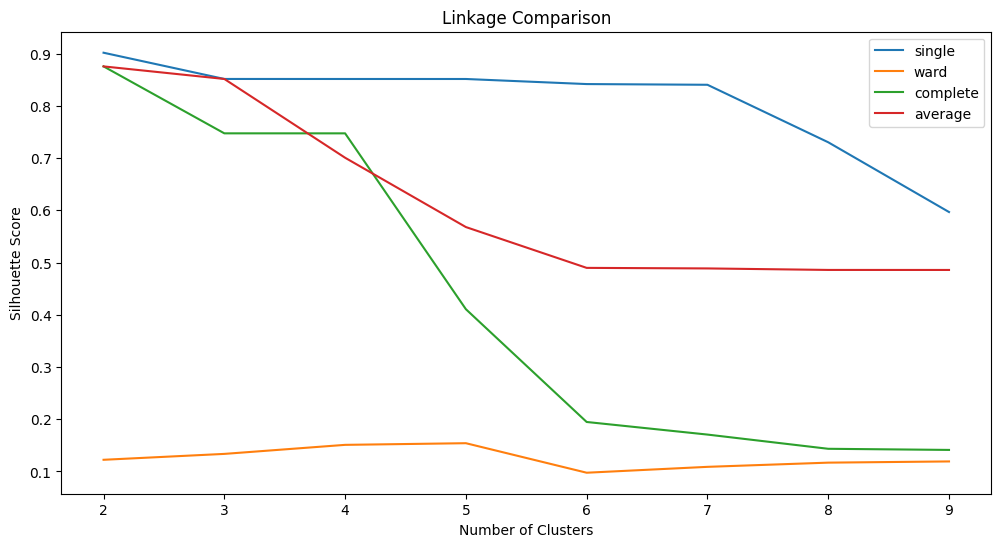

In [10]:
plt.figure(figsize= (12, 6))
plt.plot(range_n_clusters, single_link_scores, label='single')
plt.plot(range_n_clusters, ward_link_scores, label='ward')
plt.plot(range_n_clusters, complete_link_scores, label='complete')
plt.plot(range_n_clusters, average_link_scores, label='average')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Linkage Comparison")
plt.legend()
plt.show()

In [11]:
def best_k(scores, k_range):
    best_k = k_range[np.argmax(scores)]
    best_score = max(scores)
    return best_k, best_score

In [12]:
print("Single:", best_k(single_link_scores, range_n_clusters))
print("Ward:", best_k(ward_link_scores, range_n_clusters))
print("Complete:", best_k(complete_link_scores, range_n_clusters))
print("Average:", best_k(average_link_scores, range_n_clusters))

Single: (2, 0.9019120842305416)
Ward: (5, 0.1541227400543926)
Complete: (2, 0.8757188043938852)
Average: (2, 0.8757188043938852)


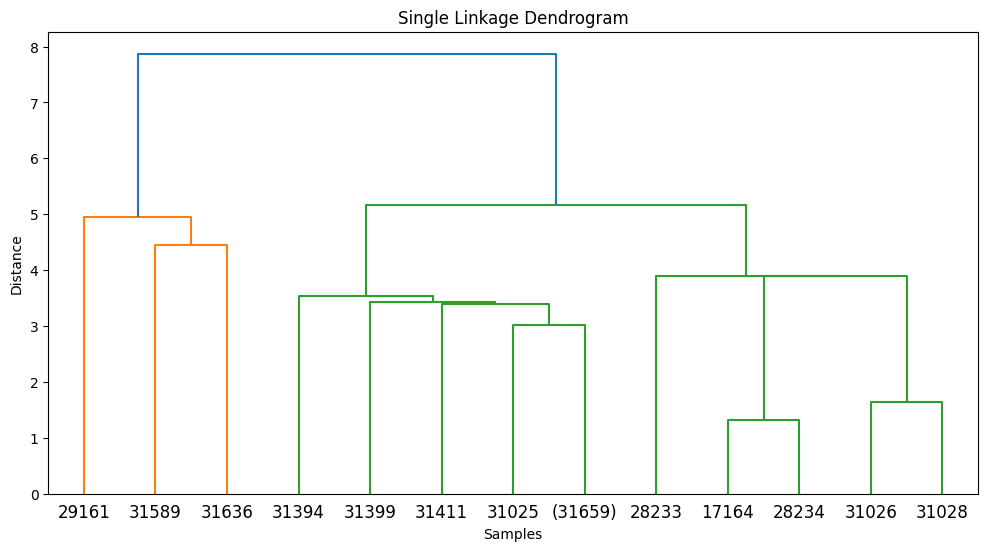

In [13]:
Z_single = linkage(x_cluster, method='single')

plt.figure(figsize=(12, 6))
dendrogram(Z_single, truncate_mode='level', p=5)
plt.title("Single Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

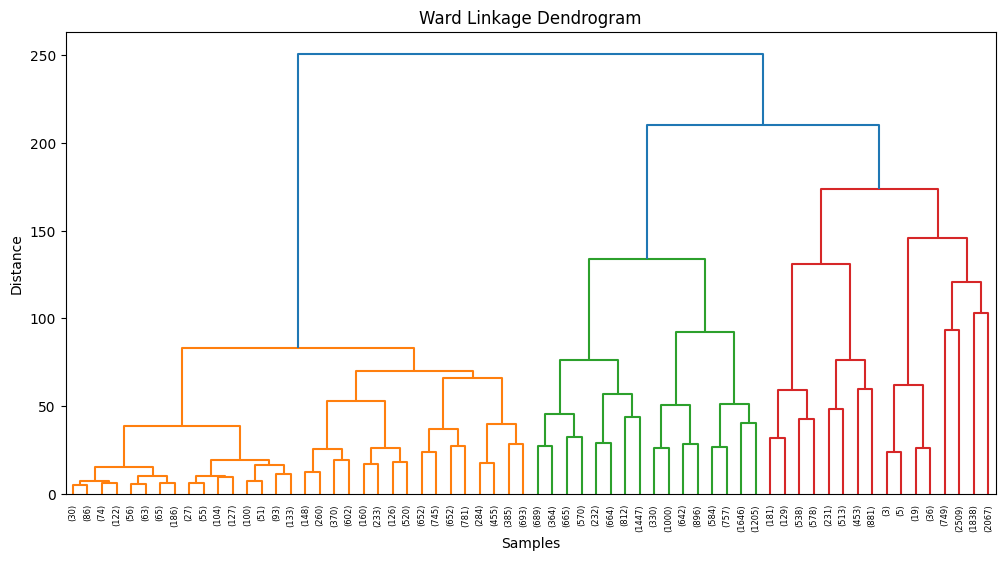

In [14]:
Z_ward = linkage(x_cluster, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z_ward, truncate_mode='level', p=5)
plt.title("Ward Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

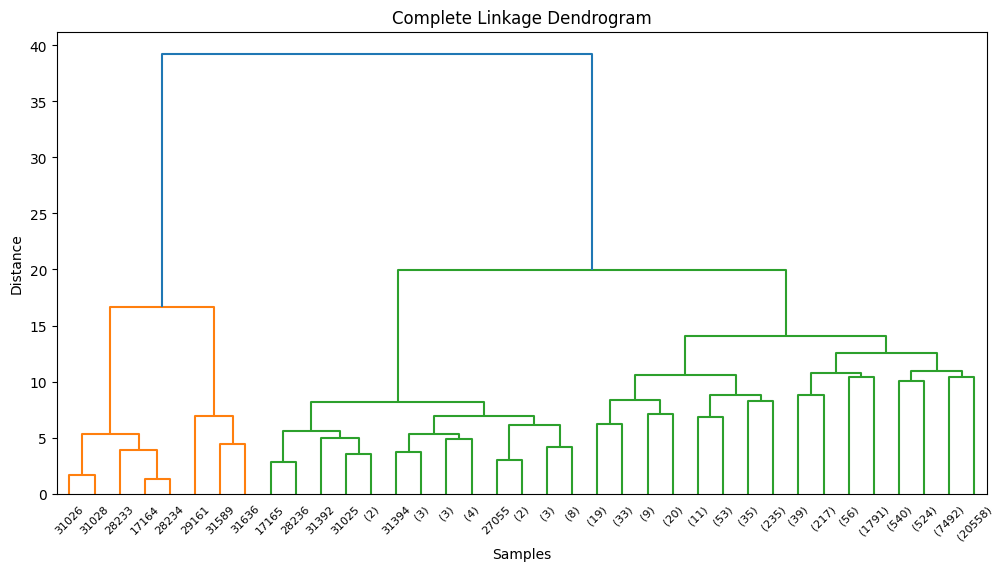

In [15]:
Z_complete = linkage(x_cluster, method='complete')

plt.figure(figsize=(12, 6))
dendrogram(Z_complete, truncate_mode='level', p=5)
plt.title("Complete Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

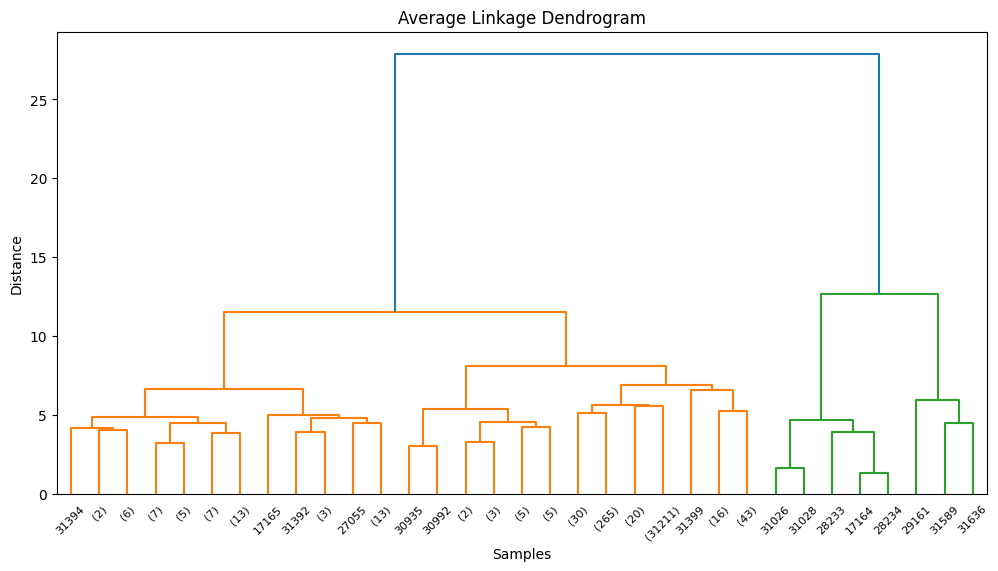

In [16]:
Z_average = linkage(x_cluster, method='average')

plt.figure(figsize=(12, 6))
dendrogram(Z_average, truncate_mode='level', p=5)
plt.title("Average Linkage Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Final Model

In [6]:
final_model2 = AgglomerativeClustering(n_clusters= 3, linkage= 'ward', metric= 'euclidean') # Default metric is `euclidean` 

clusters2 = final_model2.fit_predict(x_cluster)

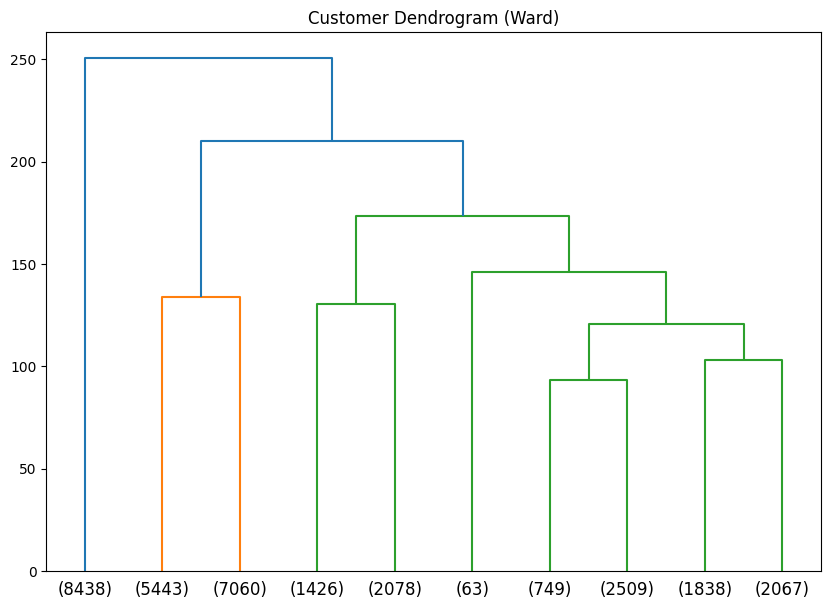

In [7]:
import scipy.cluster.hierarchy as shc


plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram (Ward)")
# Use a sample so the plot is readable
dend = shc.dendrogram(shc.linkage(x_cluster, method='ward'),truncate_mode="lastp",p=10)
plt.show()

In [8]:
data_with_clusters2 = pd.read_csv('cleaned_data.csv') 

In [9]:
data_with_clusters2['ward_cluster'] = clusters2

In [10]:
data_with_clusters2.head(30) 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,ward_cluster
0,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,False,True,False,False,False,False,False,False,2
1,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,False,False,False,True,False,False,False,False,False,0
2,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,False,False,False,True,False,False,False,False,False,0
3,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,False,False,False,True,False,False,False,False,True,0
4,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,False,True,False,False,False,False,False,False,False,1
5,26,77100,8.0,35000,0.1242,1,0.45,3,False,False,...,False,False,True,False,False,False,False,False,False,0
6,24,78956,5.0,35000,0.1111,1,0.44,4,False,False,...,False,False,True,False,False,False,False,False,False,0
7,24,83000,8.0,35000,0.0890,1,0.42,2,False,False,...,True,False,False,False,False,False,False,False,False,0
8,22,85000,6.0,35000,0.1037,1,0.41,4,False,False,...,False,True,True,False,False,False,False,False,False,0
9,21,10000,2.0,4500,0.0863,1,0.45,2,False,True,...,False,False,False,False,False,False,False,False,False,1


In [11]:
data_with_clusters2.tail(20)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,ward_cluster
31651,54,129000,6.0,9000,0.114900,1,0.07,24,False,False,...,False,False,True,False,False,False,False,False,False,0
31652,61,160000,30.0,24000,0.103800,0,0.15,21,False,False,...,True,False,True,False,False,False,False,False,False,0
31653,52,71520,0.0,7000,0.168200,1,0.10,24,False,False,...,False,False,False,False,False,True,False,False,True,0
31654,53,45000,0.0,5600,0.137900,0,0.12,28,False,False,...,True,False,False,True,False,False,False,False,False,0
31655,57,40000,1.0,15000,0.089000,1,0.38,21,False,False,...,False,False,False,False,False,False,False,False,False,0
31656,52,30000,6.0,5000,0.127300,0,0.17,18,False,False,...,False,True,False,True,False,False,False,False,False,0
31657,53,85000,2.0,8000,0.077400,0,0.09,26,False,False,...,True,False,False,False,False,False,False,False,False,0
31658,60,49008,5.0,12000,0.137900,0,0.24,21,False,True,...,True,False,False,True,False,False,False,False,True,0
31659,51,60000,1.0,7500,0.073284,0,0.13,23,False,False,...,True,False,False,False,False,False,False,False,False,0
31660,58,72000,5.0,4500,0.109958,0,0.06,23,False,False,...,False,False,True,False,False,False,False,False,False,0


In [12]:
data_with_clusters2['ward_cluster'].value_counts()

ward_cluster
2    12503
0    10730
1     8438
Name: count, dtype: int64

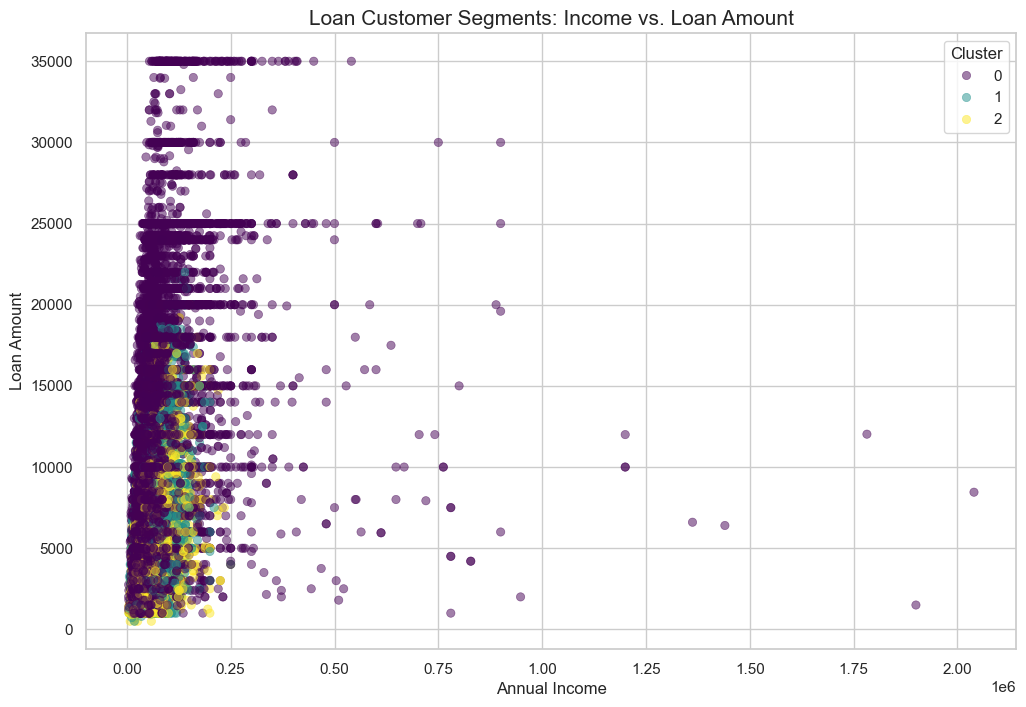

In [13]:
import seaborn as sns

# Setting the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Using the original feature names for the axes
# I've added a log scale for income in case you have high-earners that squash the plot
plot = sns.scatterplot(
    data=data_with_clusters2, 
    x='person_income', 
    y='loan_amnt', 
    hue='ward_cluster', 
    palette='viridis', 
    alpha=0.5,
    edgecolor=None
)

plt.title('Loan Customer Segments: Income vs. Loan Amount', fontsize=15)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Loan Amount', fontsize=12)
plt.legend(title='Cluster')

# Optional: If your income data has extreme outliers, uncomment the line below:
# plt.xscale('log') 

plt.show()

In [14]:
# This gives you the average 'vibe' of each cluster
profile = data_with_clusters2.groupby('ward_cluster')[['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']].mean()
print(profile)

              person_age  person_income     loan_amnt  loan_int_rate
ward_cluster                                                        
0              31.007269   82959.476887  14762.374185       0.117383
1              26.239512   61660.585210   7408.941692       0.073063
2              26.081021   53996.910741   6583.334000       0.129100


## Customer Persona Analysis

After applying Ward Linkage Hierarchical Clustering, three distinct customer segments were identified. The clusters are relatively well-balanced, allowing for meaningful segmentation and interpretation.

---

### Cluster 0: "The Affluent Borrowers"
* Average Age: ~31 years (Mid-career individuals).
* Average Income: ~$83,000 (Highest income group).
* Loan Behavior: They take the largest loan amounts (~$14.7k) with moderate interest rates (~11.7%).

> **Business Insight**: These customers are financially strong and capable of handling larger loans. They represent a high-value segment suitable for premium loan products, higher credit limits, and long-term financial services.

---

### Cluster 1: "The Low-Risk Starters"
* Average Age: ~26 years (Young professionals).
* Average Income: ~$61,000 (Moderate income level).
* Loan Behavior: They take moderate loans (~$7.4k) with the lowest interest rates (~7.3%).

> **Business Insight**: This is the lowest-risk segment. Their borrowing behavior is cautious and stable, making them ideal candidates for customer retention strategies and gradual credit expansion.

---

### Cluster 2: "The High-Risk Borrowers"
* Average Age: ~26 years (Similar to Cluster 1, early-career stage).
* Average Income: ~$54,000 (Lowest income group).
* Loan Behavior: They take smaller loans (~$6.5k) but face the highest interest rates (~12.9%).

> **Business Insight**: This segment reflects higher financial risk. Despite smaller loan sizes, the high interest rates suggest lower creditworthiness. These customers may require stricter approval criteria or risk-adjusted financial products.

## Final Insight

Unlike previous clustering attempts, Ward linkage produced balanced and interpretable clusters, enabling clear differentiation between high-value, low-risk, and high-risk customer groups. This segmentation provides a strong foundation for downstream tasks such as risk modeling, targeted marketing, and decision-making systems.

In [15]:
cluster_map = {
    0: 'Affluent Borrowers',  # They can afford larger loans, Not necessarily safest, but financially strong
    1: 'Low-Risk Starters', # Banks trust them → lowest interest,  Careful borrowers → smaller loans
    2: 'High-Risk Borrowers' # Clear risk profile, Even with smaller loans → high interest
}

data_with_clusters2['cluster_name'] = data_with_clusters2['ward_cluster'].map(cluster_map)

# Now your counts are readable!
print(data_with_clusters2['cluster_name'].value_counts())

cluster_name
High-Risk Borrowers    12503
Affluent Borrowers     10730
Low-Risk Starters       8438
Name: count, dtype: int64


In [16]:
data_with_clusters2.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y,ward_cluster,cluster_name
0,21,9600,5.0,1000,0.1114,0,0.10,2,False,True,...,False,True,False,False,False,False,False,False,2,High-Risk Borrowers
1,25,9600,1.0,5500,0.1287,1,0.57,3,False,False,...,False,False,True,False,False,False,False,False,0,Affluent Borrowers
2,23,65500,4.0,35000,0.1523,1,0.53,2,False,False,...,False,False,True,False,False,False,False,False,0,Affluent Borrowers
3,24,54400,8.0,35000,0.1427,1,0.55,4,False,False,...,False,False,True,False,False,False,False,True,0,Affluent Borrowers
4,21,9900,2.0,2500,0.0714,1,0.25,2,False,True,...,True,False,False,False,False,False,False,False,1,Low-Risk Starters


## Final Analysis 

| Feature | Using 0, 1, 2 | Using Names |
| :--- | :--- | :--- |
| **Communication** | "Cluster 2 has the highest interest rates." | "High-Risk Borrowers are charged higher interest due to increased credit risk." |
| **Actionability** | "Target Cluster 0." | "Offer premium loan products to Affluent Borrowers." |
| **Risk Strategy** | "Cluster 2 is risky." | "Apply stricter approval policies for High-Risk Borrowers." |
| **Customer Growth** | "Cluster 1 has moderate values." | "Support Low-Risk Starters with gradual credit expansion." |
| **Professionalism** | Looks like a technical exercise. | Looks like a real-world financial segmentation strategy. |